In [1]:
import numpy as np
import pandas as pd

## DATASET: Train Set ==> BalanceClass

In [2]:
dataframe = pd.read_csv('/media/tohn/HDD/VISION_dataset/Traindf_fold4_8_v1.csv')
print(dataframe.shape)
dataframe.head()

(4601, 27)


,Unnamed: 0,Case,Abs Position,Sub Position,Class,Path Full,Path Crop,Views,fold,15AB,...,Rwidth,Rheight,Sub_class_New,tag_AjNit,tag_AjWan,Test150,Spilt,Sub_Position_New,filename,Sub_Position_Label
0,34,42,P5,P52,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,7,MildFattyLiver,...,0.633663,0.651394,AB01,NaN,NaN,False,Train,None,AB01 P5-2 C042.JPG,P7
1,35,42,P1,P1,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,7,ModerateFattyLiver,...,0.541516,0.422222,AB02,NaN,NaN,False,Train,P1,AB02 P1 C042.JPG,P1
2,36,42,P2,P2,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,7,ModerateFattyLiver,...,0.494585,0.610101,AB02,NaN,NaN,False,Train,P2,AB02 P2 C042.JPG,P2
3,37,42,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,7,ModerateFattyLiver,...,0.494545,0.668687,AB02,NaN,NaN,False,Train,P6,AB02 P5-1 C042.JPG,P6
4,38,42,P4,P42,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,7,ModerateFattyLiver,...,0.477148,0.690909,AB02,NaN,NaN,False,Train,P5,AB02 P4-2 C042.JPG,P5


In [3]:
dataframe["Path Crop"].tolist()

['/media/tohn/HDD/VISION_dataset/USAI/ABnormal01/1 ABNORMAL/cropped/AB01 P5-2 C042.JPG',
 '/media/tohn/HDD/VISION_dataset/USAI/ABnormal01/2 ABNORMAL/cropped/AB02 P1 C042.JPG',
 '/media/tohn/HDD/VISION_dataset/USAI/ABnormal01/2 ABNORMAL/cropped/AB02 P2 C042.JPG',
 '/media/tohn/HDD/VISION_dataset/USAI/ABnormal01/2 ABNORMAL/cropped/AB02 P5-1 C042.JPG',
 '/media/tohn/HDD/VISION_dataset/USAI/ABnormal01/2 ABNORMAL/cropped/AB02 P4-2 C042.JPG',
 '/media/tohn/HDD/VISION_dataset/USAI/ABnormal01/2 ABNORMAL/cropped/AB02 P4-1 C042.JPG',
 '/media/tohn/HDD/VISION_dataset/USAI/ABnormal01/4 ABNORMAL/cropped/AB04 P1 C042.JPG',
 '/media/tohn/HDD/VISION_dataset/USAI/ABnormal01/4 ABNORMAL/cropped/AB04 P2 C042.JPG',
 '/media/tohn/HDD/VISION_dataset/USAI/ABnormal01/5 ABNORMAL/cropped/AB05 P3-1 C042.JPG',
 '/media/tohn/HDD/VISION_dataset/USAI/ABnormal01/6 ABNORMAL/cropped/AB06 P2 C042.JPG',
 '/media/tohn/HDD/VISION_dataset/USAI/ABnormal01/6 ABNORMAL/cropped/AB06 P1 C042.JPG',
 '/media/tohn/HDD/VISION_dataset/

In [5]:
# Select 20 random rows without replacement and set random_state for reproducibility
random_rows = dataframe.sample(n=40, replace=False, random_state=42)
print(random_rows.shape)
random_rows1 = random_rows.iloc[:20,:]
random_rows1 = random_rows1.reset_index(drop=True)
print(random_rows1.shape)
random_rows2 = random_rows.iloc[20:,:]
random_rows2 = random_rows2.reset_index(drop=True)
print(random_rows2.shape)

(40, 27)
(20, 27)
(20, 27)


<Figure size 864x864 with 0 Axes>

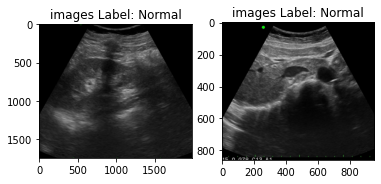

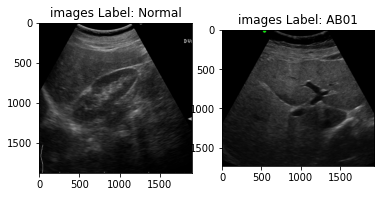

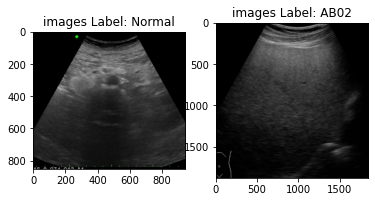

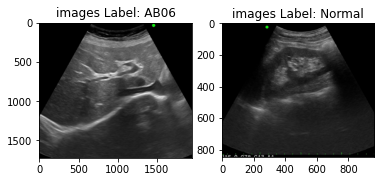

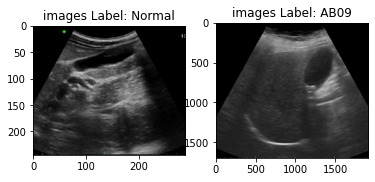

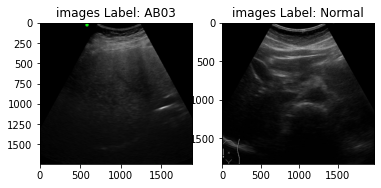

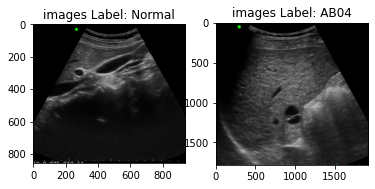

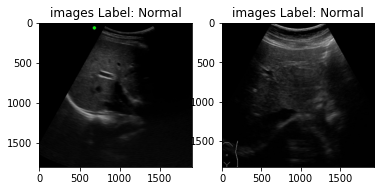

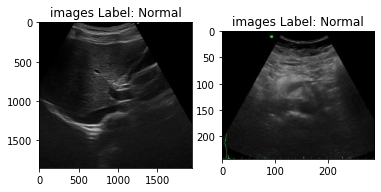

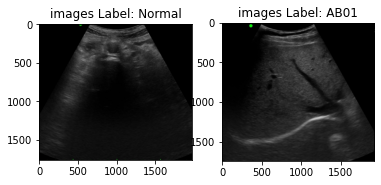

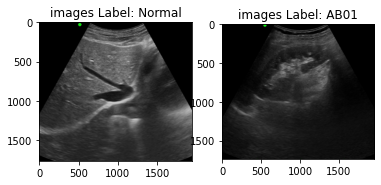

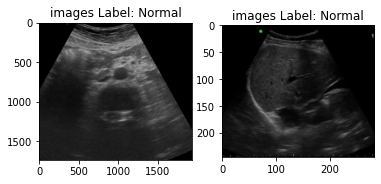

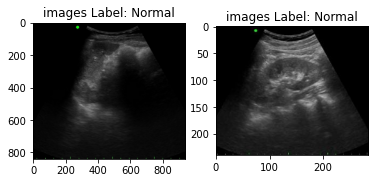

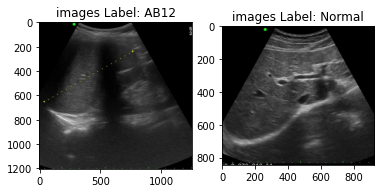

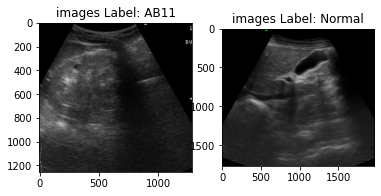

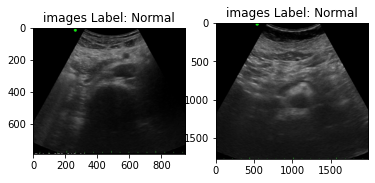

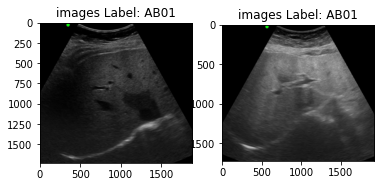

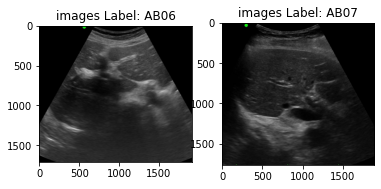

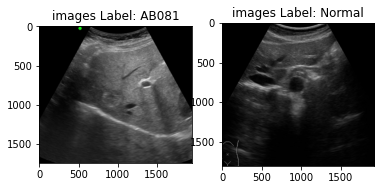

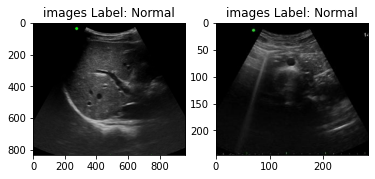

In [8]:
import cv2 
import PIL
from PIL import Image

%matplotlib inline
from matplotlib import pyplot as plt

batchXmain_train = random_rows1['Path Crop'].tolist() 
batchX2_train = random_rows2['Path Crop'].tolist()
batchYmain_train = random_rows1['Sub_class_New'].tolist()
batchY2_train = random_rows2['Sub_class_New'].tolist()

fig = plt.figure(figsize=(12, 12))
for i in range(len(random_rows1)):
    fig, (ax1, ax2) = plt.subplots(1, 2)
    
    array_imgMain = cv2.imread(batchXmain_train[i])
    array_img2 = cv2.imread(batchX2_train[i])
    
    ax1.imshow(array_imgMain)
    ax1.set_title(f"images Label: {batchYmain_train[i]}")
    ax2.imshow(array_img2)
    ax2.set_title(f"images Label: {batchY2_train[i]}")
    plt.show()

In [16]:
import cv2

def is_valid_image(filepath):
    # Try to read the image file
    #miss_img = []
    image = cv2.imread(filepath)
    # Check if the image was loaded successfully
    if image is None:
        print(f"{filepath} >>> is not a valid image.")
        #miss_img.append(filepath)
        return False
    else:
        #print(f"{filepath} >>> is a valid image.")
        return True

In [17]:
# Test the function with an image path
filepath = dataframe["Path Crop"].tolist()
for i in range(len(filepath)):
    is_valid_image(filepath[i])

In [19]:
# Group by 'Category' and count all rows in each group
grouped_count = dataframe.groupby('Sub_class_New').size()
grouped_count

Sub_class_New
AB01       258
AB02       223
AB03        80
AB04       146
AB05        85
AB06        57
AB07        65
AB081      108
AB082      100
AB083       39
AB09        85
AB10        38
AB11       194
AB12       118
Normal    3005
dtype: int64

In [21]:
# Set the target count for each class based on the 'Normal' class
target_count = 3005

# Balance the classes except for 'Normal'
balanced_df = (
    dataframe
    .groupby('Sub_class_New', group_keys=False)
    .apply(lambda x: x if x.name == 'Normal' else x.sample(n=target_count, replace=True))
    .reset_index(drop=True)
)

print(balanced_df.shape)

(45075, 27)


In [22]:
balanced_df

,Unnamed: 0,Case,Abs Position,Sub Position,Class,Path Full,Path Crop,Views,fold,15AB,...,Rwidth,Rheight,Sub_class_New,tag_AjNit,tag_AjWan,Test150,Spilt,Sub_Position_New,filename,Sub_Position_Label
0,245,37,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,10,MildFattyLiver,...,0.624765,0.647410,AB01,NaN,NaN,False,Train,P6,AB01 P5-1 C037.JPG,P6
1,1414,88,P3,P31,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,5,MildFattyLiver,...,0.499069,0.597610,AB01,NaN,NaN,False,Train,P3,AB01 P3-1 C088.JPG,P3
2,1145,11,P4,P41,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,10,MildFattyLiver,...,0.606762,0.671315,AB01,NaN,NaN,False,Train,P4,AB01 P4-1 C011.JPG,P4
3,1470,76,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,8,MildFattyLiver,...,0.595707,0.673307,AB01,NaN,NaN,False,Train,P6,AB01 P5-1 C076.JPG,P6
4,881,14,P4,P42,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,4,MildFattyLiver,...,0.654135,0.631474,AB01,NaN,NaN,False,Train,P5,AB01 P4-2 C014.JPG,P5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45070,6564,344,P3,P32,Normal,/media/tohn/HDD/VISION_dataset/USAI/US images ...,/media/tohn/HDD/VISION_dataset/USAI/US images ...,FP-B,4,Normal,...,NaN,NaN,Normal,NaN,NaN,False,Train,P9,P3-2.Case 344.JPG,P9
45071,6565,344,P4,P42,Normal,/media/tohn/HDD/VISION_dataset/USAI/US images ...,/media/tohn/HDD/VISION_dataset/USAI/US images ...,FP-B,4,Normal,...,NaN,NaN,Normal,NaN,NaN,False,Train,P5,P4-2.Case 344.JPG,P5
45072,6566,344,P5,P52,Normal,/media/tohn/HDD/VISION_dataset/USAI/US images ...,/media/tohn/HDD/VISION_dataset/USAI/US images ...,FP-C,4,Normal,...,NaN,NaN,Normal,NaN,NaN,False,Train,None,P5-2.Case 344.JPG,P7
45073,6567,344,P6,P61,Normal,/media/tohn/HDD/VISION_dataset/USAI/US images ...,/media/tohn/HDD/VISION_dataset/USAI/US images ...,FP-C,4,Normal,...,NaN,NaN,Normal,NaN,NaN,False,Train,P14,P6.Case 344.JPG,P14


In [36]:
###balanced_df

In [37]:
balanced_df.to_csv('/media/tohn/HDD/VISION_dataset/Traindf_fold4_8_v1_Balance_classes.csv')

In [23]:
# Group by 'Category' and count all rows in each group
balanced_count = balanced_df.groupby('Sub_class_New').size()
balanced_count

Sub_class_New
AB01      3005
AB02      3005
AB03      3005
AB04      3005
AB05      3005
AB06      3005
AB07      3005
AB081     3005
AB082     3005
AB083     3005
AB09      3005
AB10      3005
AB11      3005
AB12      3005
Normal    3005
dtype: int64

In [24]:
duplicates = balanced_df[balanced_df.duplicated(subset=['Path Crop'])]
print(duplicates.shape)
duplicates

(40476, 27)


,Unnamed: 0,Case,Abs Position,Sub Position,Class,Path Full,Path Crop,Views,fold,15AB,...,Rwidth,Rheight,Sub_class_New,tag_AjNit,tag_AjWan,Test150,Spilt,Sub_Position_New,filename,Sub_Position_Label
26,1067,72,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,4,MildFattyLiver,...,0.694391,0.798805,AB01,NaN,NaN,False,Train,P6,AB01 P5-1 C072.JPG,P6
28,1423,19,P2,P2,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,9,MildFattyLiver,...,0.629032,0.571713,AB01,NaN,NaN,False,Train,P2,AB01 P2 C019.JPG,P2
29,135,13,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,8,MildFattyLiver,...,0.445672,0.589641,AB01,NaN,NaN,False,Train,P6,AB01 P5-1 C013.JPG,P6
39,883,14,P1,P1,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,4,MildFattyLiver,...,0.573260,0.555777,AB01,NaN,NaN,False,Train,P1,AB01 P1 C014.JPG,P1
45,1426,19,P4,P41,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,9,MildFattyLiver,...,0.650177,0.569721,AB01,NaN,NaN,False,Train,P4,AB01 P4-1 C019.JPG,P4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42065,1923,129,P7,P71,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABNORMAL J...,/media/tohn/HDD/VISION_dataset/USAI/ABNORMAL J...,FP-D,8,Splenomegaly,...,0.685300,0.583665,AB12,NaN,NaN,False,Train,P11,AB11 A2 P7-1.Case A2.JPG.png,P11
42066,2057,257,P7,P71,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,FP-D,4,Splenomegaly,...,0.585603,0.707171,AB12,NaN,NaN,False,Train,P11,FP D P7-1 Case 099.JPG.png,P11
42067,2072,231,P7,P71,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,FP-D,10,Splenomegaly,...,0.776000,0.581673,AB12,NaN,NaN,False,Train,P11,FP D P7-1 Case 073.JPG.png,P11
42068,2065,297,P7,P71,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,FP-D,4,Splenomegaly,...,0.706564,0.641434,AB12,NaN,NaN,False,Train,P11,FP D P7-1 Case 139.JPG.png,P11


In [25]:
duplicates.groupby('Sub_class_New').size()

Sub_class_New
AB01     2747
AB02     2782
AB03     2925
AB04     2859
AB05     2920
AB06     2948
AB07     2940
AB081    2897
AB082    2905
AB083    2966
AB09     2920
AB10     2967
AB11     2813
AB12     2887
dtype: int64

In [27]:
AB01_df = duplicates[duplicates["Sub_class_New"]=="AB01"]
print(AB01_df.shape)
AB01_df.head()

(2747, 27)


,Unnamed: 0,Case,Abs Position,Sub Position,Class,Path Full,Path Crop,Views,fold,15AB,...,Rwidth,Rheight,Sub_class_New,tag_AjNit,tag_AjWan,Test150,Spilt,Sub_Position_New,filename,Sub_Position_Label
26,1067,72,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,4,MildFattyLiver,...,0.694391,0.798805,AB01,NaN,NaN,False,Train,P6,AB01 P5-1 C072.JPG,P6
28,1423,19,P2,P2,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,9,MildFattyLiver,...,0.629032,0.571713,AB01,NaN,NaN,False,Train,P2,AB01 P2 C019.JPG,P2
29,135,13,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,8,MildFattyLiver,...,0.445672,0.589641,AB01,NaN,NaN,False,Train,P6,AB01 P5-1 C013.JPG,P6
39,883,14,P1,P1,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,4,MildFattyLiver,...,0.573260,0.555777,AB01,NaN,NaN,False,Train,P1,AB01 P1 C014.JPG,P1
45,1426,19,P4,P41,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,9,MildFattyLiver,...,0.650177,0.569721,AB01,NaN,NaN,False,Train,P4,AB01 P4-1 C019.JPG,P4


In [34]:
drop_dup_AB01 = AB01_df.drop_duplicates(subset=['Path Crop'])
print(drop_dup_AB01.shape)
drop_dup_AB01

(258, 27)


,Unnamed: 0,Case,Abs Position,Sub Position,Class,Path Full,Path Crop,Views,fold,15AB,...,Rwidth,Rheight,Sub_class_New,tag_AjNit,tag_AjWan,Test150,Spilt,Sub_Position_New,filename,Sub_Position_Label
26,1067,72,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,4,MildFattyLiver,...,0.694391,0.798805,AB01,NaN,NaN,False,Train,P6,AB01 P5-1 C072.JPG,P6
28,1423,19,P2,P2,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,9,MildFattyLiver,...,0.629032,0.571713,AB01,NaN,NaN,False,Train,P2,AB01 P2 C019.JPG,P2
29,135,13,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,8,MildFattyLiver,...,0.445672,0.589641,AB01,NaN,NaN,False,Train,P6,AB01 P5-1 C013.JPG,P6
39,883,14,P1,P1,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,4,MildFattyLiver,...,0.573260,0.555777,AB01,NaN,NaN,False,Train,P1,AB01 P1 C014.JPG,P1
45,1426,19,P4,P41,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,9,MildFattyLiver,...,0.650177,0.569721,AB01,NaN,NaN,False,Train,P4,AB01 P4-1 C019.JPG,P4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1486,34,42,P5,P52,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,7,MildFattyLiver,...,0.633663,0.651394,AB01,NaN,NaN,False,Train,None,AB01 P5-2 C042.JPG,P7
1492,698,12,P1,P1,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,8,MildFattyLiver,...,0.619390,0.617530,AB01,NaN,NaN,False,Train,P1,AB01 P1 C012.JPG,P1
1510,770,24,P2,P2,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,8,MildFattyLiver,...,0.431408,0.486056,AB01,NaN,NaN,False,Train,P2,AB01 P2 C024.JPG,P2
1516,695,12,P2,P2,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,8,MildFattyLiver,...,0.653846,0.513944,AB01,NaN,NaN,False,Train,P2,AB01 P2 C012.JPG,P2


In [29]:
AB01_df["Path Crop"].tolist()

['/media/tohn/HDD/VISION_dataset/USAI/ABnormal01/1 ABNORMAL/cropped/AB01 P5-1 C072.JPG',
 '/media/tohn/HDD/VISION_dataset/USAI/ABnormal01/1 ABNORMAL/cropped/AB01 P2 C019.JPG',
 '/media/tohn/HDD/VISION_dataset/USAI/ABnormal01/1 ABNORMAL/cropped/AB01 P5-1 C013.JPG',
 '/media/tohn/HDD/VISION_dataset/USAI/ABnormal01/1 ABNORMAL/cropped/AB01 P1 C014.JPG',
 '/media/tohn/HDD/VISION_dataset/USAI/ABnormal01/1 ABNORMAL/cropped/AB01 P4-1 C019.JPG',
 '/media/tohn/HDD/VISION_dataset/USAI/ABnormal01/1 ABNORMAL/cropped/AB01 P3-1 C076_2.JPG',
 '/media/tohn/HDD/VISION_dataset/USAI/ABnormal01/1 ABNORMAL/cropped/AB01 P2 C021.JPG',
 '/media/tohn/HDD/VISION_dataset/USAI/ABnormal01/1 ABNORMAL/cropped/AB01 P4-2 C008.JPG',
 '/media/tohn/HDD/VISION_dataset/USAI/ABnormal01/1 ABNORMAL/cropped/AB01 P1 C074.JPG',
 '/media/tohn/HDD/VISION_dataset/USAI/ABnormal01/1 ABNORMAL/cropped/AB01 P2 C051.JPG',
 '/media/tohn/HDD/VISION_dataset/USAI/ABnormal01/1 ABNORMAL/cropped/AB01 P5-2 C022.JPG',
 '/media/tohn/HDD/VISION_data

In [30]:
a = AB01_df[AB01_df["Path Crop"]=='/media/tohn/HDD/VISION_dataset/USAI/ABnormal01/1 ABNORMAL/cropped/AB01 P5-1 C072.JPG']
print(a.shape)
a

(9, 27)


,Unnamed: 0,Case,Abs Position,Sub Position,Class,Path Full,Path Crop,Views,fold,15AB,...,Rwidth,Rheight,Sub_class_New,tag_AjNit,tag_AjWan,Test150,Spilt,Sub_Position_New,filename,Sub_Position_Label
26,1067,72,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,4,MildFattyLiver,...,0.694391,0.798805,AB01,NaN,NaN,False,Train,P6,AB01 P5-1 C072.JPG,P6
269,1067,72,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,4,MildFattyLiver,...,0.694391,0.798805,AB01,NaN,NaN,False,Train,P6,AB01 P5-1 C072.JPG,P6
539,1067,72,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,4,MildFattyLiver,...,0.694391,0.798805,AB01,NaN,NaN,False,Train,P6,AB01 P5-1 C072.JPG,P6
773,1067,72,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,4,MildFattyLiver,...,0.694391,0.798805,AB01,NaN,NaN,False,Train,P6,AB01 P5-1 C072.JPG,P6
1204,1067,72,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,4,MildFattyLiver,...,0.694391,0.798805,AB01,NaN,NaN,False,Train,P6,AB01 P5-1 C072.JPG,P6
1275,1067,72,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,4,MildFattyLiver,...,0.694391,0.798805,AB01,NaN,NaN,False,Train,P6,AB01 P5-1 C072.JPG,P6
1411,1067,72,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,4,MildFattyLiver,...,0.694391,0.798805,AB01,NaN,NaN,False,Train,P6,AB01 P5-1 C072.JPG,P6
1963,1067,72,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,4,MildFattyLiver,...,0.694391,0.798805,AB01,NaN,NaN,False,Train,P6,AB01 P5-1 C072.JPG,P6
2898,1067,72,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,4,MildFattyLiver,...,0.694391,0.798805,AB01,NaN,NaN,False,Train,P6,AB01 P5-1 C072.JPG,P6


In [31]:
a["Path Crop"].tolist()

['/media/tohn/HDD/VISION_dataset/USAI/ABnormal01/1 ABNORMAL/cropped/AB01 P5-1 C072.JPG',
 '/media/tohn/HDD/VISION_dataset/USAI/ABnormal01/1 ABNORMAL/cropped/AB01 P5-1 C072.JPG',
 '/media/tohn/HDD/VISION_dataset/USAI/ABnormal01/1 ABNORMAL/cropped/AB01 P5-1 C072.JPG',
 '/media/tohn/HDD/VISION_dataset/USAI/ABnormal01/1 ABNORMAL/cropped/AB01 P5-1 C072.JPG',
 '/media/tohn/HDD/VISION_dataset/USAI/ABnormal01/1 ABNORMAL/cropped/AB01 P5-1 C072.JPG',
 '/media/tohn/HDD/VISION_dataset/USAI/ABnormal01/1 ABNORMAL/cropped/AB01 P5-1 C072.JPG',
 '/media/tohn/HDD/VISION_dataset/USAI/ABnormal01/1 ABNORMAL/cropped/AB01 P5-1 C072.JPG',
 '/media/tohn/HDD/VISION_dataset/USAI/ABnormal01/1 ABNORMAL/cropped/AB01 P5-1 C072.JPG',
 '/media/tohn/HDD/VISION_dataset/USAI/ABnormal01/1 ABNORMAL/cropped/AB01 P5-1 C072.JPG']

### Validation Set

In [16]:
valframe = pd.read_csv('/media/tohn/HDD/VISION_dataset/Valdf_fold3_v1.csv')
print(valframe.shape)
valframe.head()

(656, 27)


,Unnamed: 0,Case,Abs Position,Sub Position,Class,Path Full,Path Crop,Views,fold,15AB,...,Rwidth,Rheight,Sub_class_New,tag_AjNit,tag_AjWan,Test150,Spilt,Sub_Position_New,filename,Sub_Position_Label
0,0,15,P3,P31,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,3,MildFattyLiver,...,0.712707,0.649402,AB01,NaN,NaN,False,Train,P3,AB01 P3-1 C015.JPG,P3
1,1,15,P1,P1,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,3,MildFattyLiver,...,0.595628,0.683267,AB01,NaN,NaN,False,Train,P1,AB01 P1 C015.JPG,P1
2,2,15,P2,P2,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,3,MildFattyLiver,...,0.497278,0.501992,AB01,NaN,NaN,False,Train,P2,AB01 P2 C015.JPG,P2
3,3,15,P4,P42,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,3,MildFattyLiver,...,0.718412,0.679283,AB01,NaN,NaN,False,Train,P5,AB01 P4-2 C015.JPG,P5
4,4,15,P4,P41,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,3,MildFattyLiver,...,0.608229,0.577689,AB01,NaN,NaN,False,Train,P4,AB01 P4-1 C015.JPG,P4


In [17]:
valframe.groupby('Sub_class_New').size()

Sub_class_New
AB01       37
AB02       46
AB03        9
AB04       16
AB05       13
AB06        7
AB07        9
AB081      16
AB082       9
AB083       4
AB09       13
AB10        5
AB11       27
AB12       16
Normal    429
dtype: int64